In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

In [3]:
cic = pd.read_csv("../data/processed/cicids2017_wednesday_clean.csv")
print(cic.shape)

(610492, 80)


In [5]:
# Remove near-duplicates/redundant features (based on correlation)

# Full correlation matric on cleaned CICIDS2017 data (numeric features only)
X_cic = cic.drop(columns=['Label', 'Label_binary'])
corr_matrix = X_cic.corr().abs()

# Get upper triangle of correlation matrix (avoid duplicate pairs)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correletaion above 0.9 with any feature
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
print("Features to drop due to high correleation:", len(to_drop))
print(to_drop)

X_cic_reduced = X_cic.drop(columns=to_drop)
print("Shape before:", X_cic.shape, "| Shape after:", X_cic_reduced.shape)

Features to drop due to high correleation: 32
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Max', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'act_data_pkt_fwd', 'Idle Mean', 'Idle Max', 'Idle Min']
Shape before: (610492, 78) | Shape after: (610492, 46)


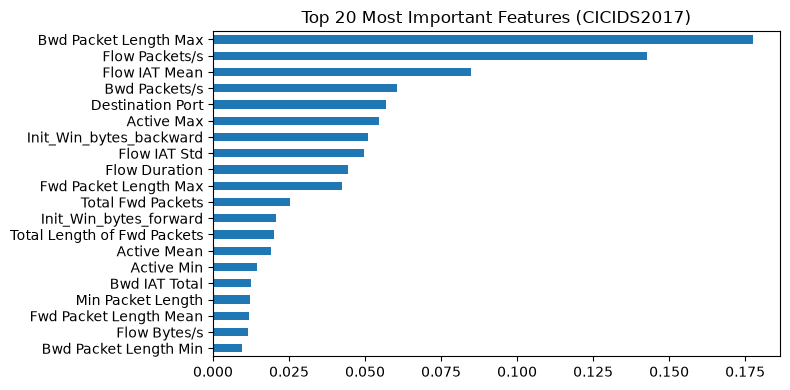

Bwd Packet Length Max          0.177572
Flow Packets/s                 0.142798
Flow IAT Mean                  0.084904
Bwd Packets/s                  0.060467
Destination Port               0.057036
Active Max                     0.054602
Init_Win_bytes_backward        0.051105
Flow IAT Std                   0.049725
Flow Duration                  0.044255
Fwd Packet Length Max          0.042561
Total Fwd Packets              0.025317
Init_Win_bytes_forward         0.020577
Total Length of Fwd Packets    0.019915
Active Mean                    0.019144
Active Min                     0.014605
Bwd IAT Total                  0.012601
Min Packet Length              0.012047
Fwd Packet Length Mean         0.011986
Flow Bytes/s                   0.011505
Bwd Packet Length Min          0.009473
dtype: float64


In [6]:
# Rank remaining features by imoportance using a quick Random Forest

y_cic = cic['Label_binary']

# Quick fit for feature importance ranking
rf_quick = RandomForestClassifier(n_estimators=50, random_state = 42, n_jobs=-1)
rf_quick.fit(X_cic_reduced, y_cic)

importances = pd.Series(rf_quick.feature_importances_, index = X_cic_reduced.columns)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(8,4))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 20 Most Important Features (CICIDS2017)")
plt.tight_layout()
plt.show()

print(top_features)

In [7]:
X_cic_reduced.to_csv("../data/processed/cicids2017_features_reduced.csv", index=False)
y_cic.to_csv("../data/processed/cicids2017_labels.csv", index=False)

top_features.to_csv("../data/processed/top_features_ranking.csv")